# Prédiction du Nombre d'Adhérents Scouts (Régression)

**Méthodologie CRISP-DM**  
**Fichier de base :** `Membres_par_Unite_et_Saison.xlsx`

## 1. Compréhension du Problème (Business Understanding)

Prédire le **nombre futur d'adhérents** par unité et par saison afin d'anticiper les besoins en encadrement et en logistique.

**Variable cible :** `Nb_Adherents` (quantitative continue → problème de **régression**)

## 2. Compréhension des Données (Data Understanding)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 300
unites = ['Louveaux', 'Scouts', 'Pionniers', 'Routiers']
saisons = [2022, 2023, 2024, 2025]

df = pd.DataFrame({
    'Unite':          np.random.choice(unites, n),
    'Saison_Debut':   np.random.choice(saisons, n),
    'Nb_Chefs_Dispo': np.random.randint(2, 6, n),
    'Budget_Alloue':  np.random.normal(1500, 300, n).round(2),
})
df['Nb_Adherents'] = (df['Nb_Chefs_Dispo'] * 8
                      + df['Budget_Alloue'] / 100
                      + np.random.normal(0, 3, n)).astype(int)

print(f"Dimensions : {df.shape}")
print(f"Types      :\n{df.dtypes}")
df.head(8)

Dimensions : (300, 5)
Types      :
Unite              object
Saison_Debut        int64
Nb_Chefs_Dispo      int32
Budget_Alloue     float64
Nb_Adherents        int64
dtype: object


,Unite,Saison_Debut,Nb_Chefs_Dispo,Budget_Alloue,Nb_Adherents
0,Pionniers,2022,2,1593.27,37
1,Routiers,2022,5,1942.61,62
2,Louveaux,2024,5,1757.30,56
3,Pionniers,2023,3,1452.02,35
4,Pionniers,2023,4,1494.30,54
5,Routiers,2022,4,1199.24,44
6,Louveaux,2025,4,1494.45,46
7,Louveaux,2023,5,1413.40,54


In [2]:
df.describe().round(2)

,Saison_Debut,Nb_Chefs_Dispo,Budget_Alloue,Nb_Adherents
count,300.00,300.00,300.00,300.00
mean,2023.62,3.43,1493.55,42.12
std,1.14,1.16,304.74,10.16
min,2022.00,2.00,690.93,21.00
25%,2023.00,2.00,1270.71,34.00
50%,2024.00,3.00,1492.24,41.00
75%,2025.00,5.00,1692.09,51.00
max,2025.00,5.00,2423.66,64.00


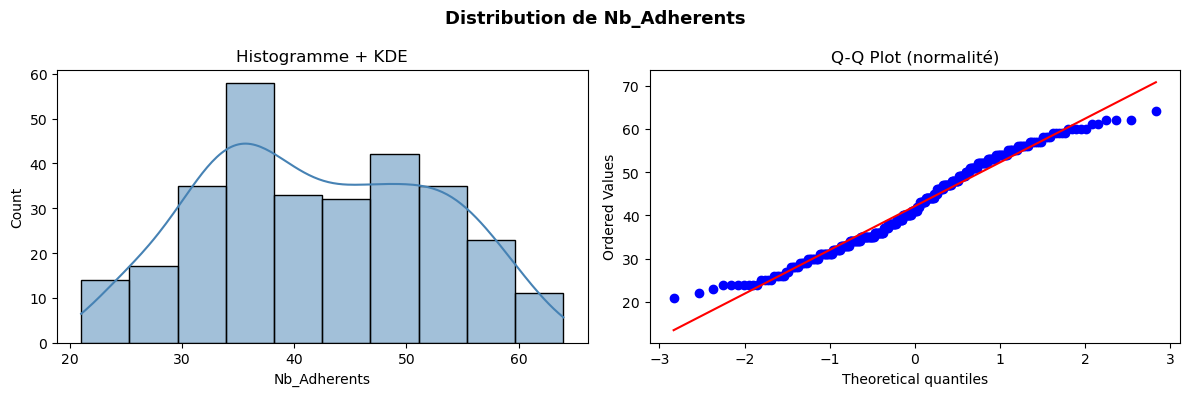

Skewness : 0.079
Kurtosis : -0.976


In [3]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribution de Nb_Adherents", fontsize=13, fontweight='bold')

sns.histplot(df['Nb_Adherents'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Histogramme + KDE")

stats.probplot(df['Nb_Adherents'], plot=axes[1])
axes[1].set_title("Q-Q Plot (normalité)")

plt.tight_layout()
plt.show()

print(f"Skewness : {df['Nb_Adherents'].skew():.3f}")
print(f"Kurtosis : {df['Nb_Adherents'].kurt():.3f}")

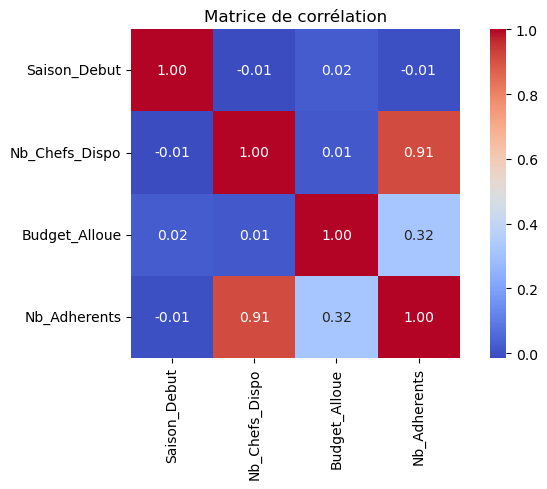

In [4]:
# Corrélations numériques
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

## 3. Préparation des Données (Data Preparation)

### A — Data Cleaning

In [5]:
# ── Valeurs manquantes ───────────────────────────────────────
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print(f"Total : {df.isnull().sum().sum()}")

Valeurs manquantes par colonne :
Unite             0
Saison_Debut      0
Nb_Chefs_Dispo    0
Budget_Alloue     0
Nb_Adherents      0
dtype: int64
Total : 0


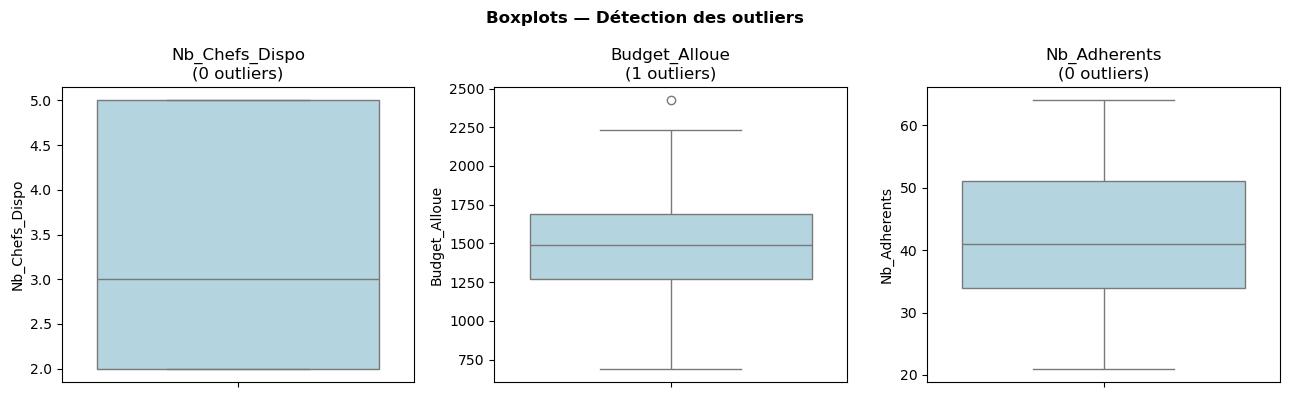


Résumé outliers (méthode IQR) : {'Nb_Chefs_Dispo': np.int64(0), 'Budget_Alloue': np.int64(1), 'Nb_Adherents': np.int64(0)}


In [6]:
# ── Détection des outliers (méthode IQR) ─────────────────────
num_cols = ['Nb_Chefs_Dispo', 'Budget_Alloue', 'Nb_Adherents']

fig, axes = plt.subplots(1, len(num_cols), figsize=(13, 4))
fig.suptitle("Boxplots — Détection des outliers", fontsize=12, fontweight='bold')

outliers_summary = {}
for ax, col in zip(axes, num_cols):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
    outliers_summary[col] = mask.sum()
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(f"{col}\n({mask.sum()} outliers)")

plt.tight_layout()
plt.show()
print("\nRésumé outliers (méthode IQR) :", outliers_summary)

### B — Encodage, Scaling & Feature Engineering

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Encodage LabelEncoder ─────────────────────────────────────
le = LabelEncoder()
df['Unite_enc'] = le.fit_transform(df['Unite'])
print("Encodage Unite :", dict(zip(le.classes_, le.transform(le.classes_))))

# ── Scaling StandardScaler ────────────────────────────────────
scaler = StandardScaler()
features_to_scale = ['Saison_Debut', 'Nb_Chefs_Dispo', 'Budget_Alloue', 'Unite_enc']
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("\nAprès scaling — statistiques :")
df_scaled[features_to_scale].describe().round(3)

Encodage Unite : {'Louveaux': np.int64(0), 'Pionniers': np.int64(1), 'Routiers': np.int64(2), 'Scouts': np.int64(3)}

Après scaling — statistiques :


,Saison_Debut,Nb_Chefs_Dispo,Budget_Alloue,Unite_enc
count,300.000,300.000,300.000,300.000
mean,0.000,-0.000,0.000,0.000
std,1.002,1.002,1.002,1.002
min,-1.416,-1.233,-2.638,-1.350
25%,-0.540,-1.233,-0.732,-0.436
50%,0.336,-0.371,-0.004,-0.436
75%,1.212,1.354,0.653,0.479
max,1.212,1.354,3.057,1.393


In [8]:
# ── Feature Engineering ──────────────────────────────────────
# Feature 1 : ratio budget par chef
df_scaled['Budget_par_Chef'] = df['Budget_Alloue'] / df['Nb_Chefs_Dispo']
df_scaled['Budget_par_Chef'] = StandardScaler().fit_transform(
    df_scaled[['Budget_par_Chef']])

# Feature 2 : saison récente (binaire)
df_scaled['Saison_Recente'] = (df['Saison_Debut'] >= 2024).astype(int)

print("Nouvelles features ajoutées : Budget_par_Chef, Saison_Recente")
df_scaled[['Budget_par_Chef','Saison_Recente']].head()

Nouvelles features ajoutées : Budget_par_Chef, Saison_Recente


,Budget_par_Chef,Saison_Recente
0,1.441417,0
1,-0.498350,0
2,-0.674507,1
3,-0.044510,0
4,-0.569394,0


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_regression, SelectKBest

FEATURES = ['Saison_Debut', 'Nb_Chefs_Dispo', 'Budget_Alloue',
            'Unite_enc', 'Budget_par_Chef', 'Saison_Recente']
TARGET   = 'Nb_Adherents'

X = df_scaled[FEATURES]
y = df[TARGET]

# ── Feature selection (Filter — F-test) ───────────────────────
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)
scores_df = pd.DataFrame({'Feature': FEATURES,
                          'F-score': selector.scores_.round(2),
                          'p-value': selector.pvalues_.round(4)
                         }).sort_values('F-score', ascending=False)
print(scores_df.to_string(index=False))

# On garde les features avec p < 0.05
selected = scores_df[scores_df['p-value'] < 0.05]['Feature'].tolist()
print(f"\nFeatures sélectionnées : {selected}")

X = df_scaled[selected]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

        Feature  F-score  p-value
 Nb_Chefs_Dispo  1442.49   0.0000
Budget_par_Chef   151.54   0.0000
  Budget_Alloue    32.83   0.0000
 Saison_Recente     0.94   0.3318
      Unite_enc     0.41   0.5232
   Saison_Debut     0.01   0.9280

Features sélectionnées : ['Nb_Chefs_Dispo', 'Budget_par_Chef', 'Budget_Alloue']
Train: (240, 3) | Test: (60, 3)


## 4. Modélisation (Modeling)

### Explication des modèles

**Régression Linéaire**
- **Intuition :** Ajuste un hyperplan qui minimise la somme des erreurs quadratiques.
- **Paramètres :** coefficients (β), intercept.
- **Hypothèses :** linéarité, indépendance des résidus, homoscédasticité, normalité des résidus.
- **Limites :** ne capture pas les relations non-linéaires.
- **Justification :** modèle baseline simple, interprétable, efficace si les relations sont linéaires.

**Decision Tree Regressor**
- **Intuition :** Partitionne l'espace des features en régions rectangulaires et prédit la moyenne de chaque région.
- **Paramètres :** `max_depth` (contrôle l'overfitting), `min_samples_split`.
- **Hypothèses :** aucune sur la distribution des données.
- **Limites :** tend à overfitter sans élagage.
- **Justification :** capture les non-linéarités, bon modèle de comparaison avec la régression linéaire.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ── Modèle 1 : Régression Linéaire ───────────────────────────
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

cv_lr = cross_val_score(model_lr, X, y, cv=kf, scoring='neg_root_mean_squared_error')
print("Régression Linéaire — CV RMSE :", (-cv_lr).round(3))
print(f"  Moyenne : {(-cv_lr).mean():.4f}  |  Std : {(-cv_lr).std():.4f}")

Régression Linéaire — CV RMSE : [2.851 2.855 2.979 2.807 3.019]
  Moyenne : 2.9021  |  Std : 0.0820


In [11]:
# ── Modèle 2 : Decision Tree Regressor ───────────────────────
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': [3, 5, 7, None],
              'min_samples_split': [2, 5, 10]}
grid_dt = GridSearchCV(DecisionTreeRegressor(random_state=42),
                       param_grid, cv=kf,
                       scoring='neg_root_mean_squared_error',
                       n_jobs=-1)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print(f"Meilleurs paramètres DT : {grid_dt.best_params_}")
cv_dt = cross_val_score(best_dt, X, y, cv=kf, scoring='neg_root_mean_squared_error')
print("Decision Tree — CV RMSE :", (-cv_dt).round(3))
print(f"  Moyenne : {(-cv_dt).mean():.4f}  |  Std : {(-cv_dt).std():.4f}")

Meilleurs paramètres DT : {'max_depth': 5, 'min_samples_split': 10}
Decision Tree — CV RMSE : [3.507 3.279 3.312 3.47  3.175]
  Moyenne : 3.3489  |  Std : 0.1233


## 5. Évaluation — Métriques & Graphiques

In [12]:
def regression_metrics(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:<28}  MSE={mse:7.3f}  RMSE={rmse:6.3f}  MAE={mae:6.3f}  R²={r2:.4f}")
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

print(f"{'Modèle':<28}  {'MSE':>9}  {'RMSE':>6}  {'MAE':>6}  {'R²':>6}")
print("─" * 65)
m_lr = regression_metrics("Régression Linéaire", y_test, y_pred_lr)
m_dt = regression_metrics("Decision Tree Regressor", y_test, y_pred_dt)

best_name = "Régression Linéaire" if m_lr['RMSE'] <= m_dt['RMSE'] else "Decision Tree Regressor"
best_pred = y_pred_lr if m_lr['RMSE'] <= m_dt['RMSE'] else y_pred_dt
best_model = model_lr if m_lr['RMSE'] <= m_dt['RMSE'] else best_dt
print(f"\n🏆 Meilleur modèle : {best_name}")

Modèle                              MSE    RMSE     MAE      R²
─────────────────────────────────────────────────────────────────
  Régression Linéaire           MSE=  8.127  RMSE= 2.851  MAE= 2.368  R²=0.9377
  Decision Tree Regressor       MSE= 12.298  RMSE= 3.507  MAE= 2.944  R²=0.9058

🏆 Meilleur modèle : Régression Linéaire


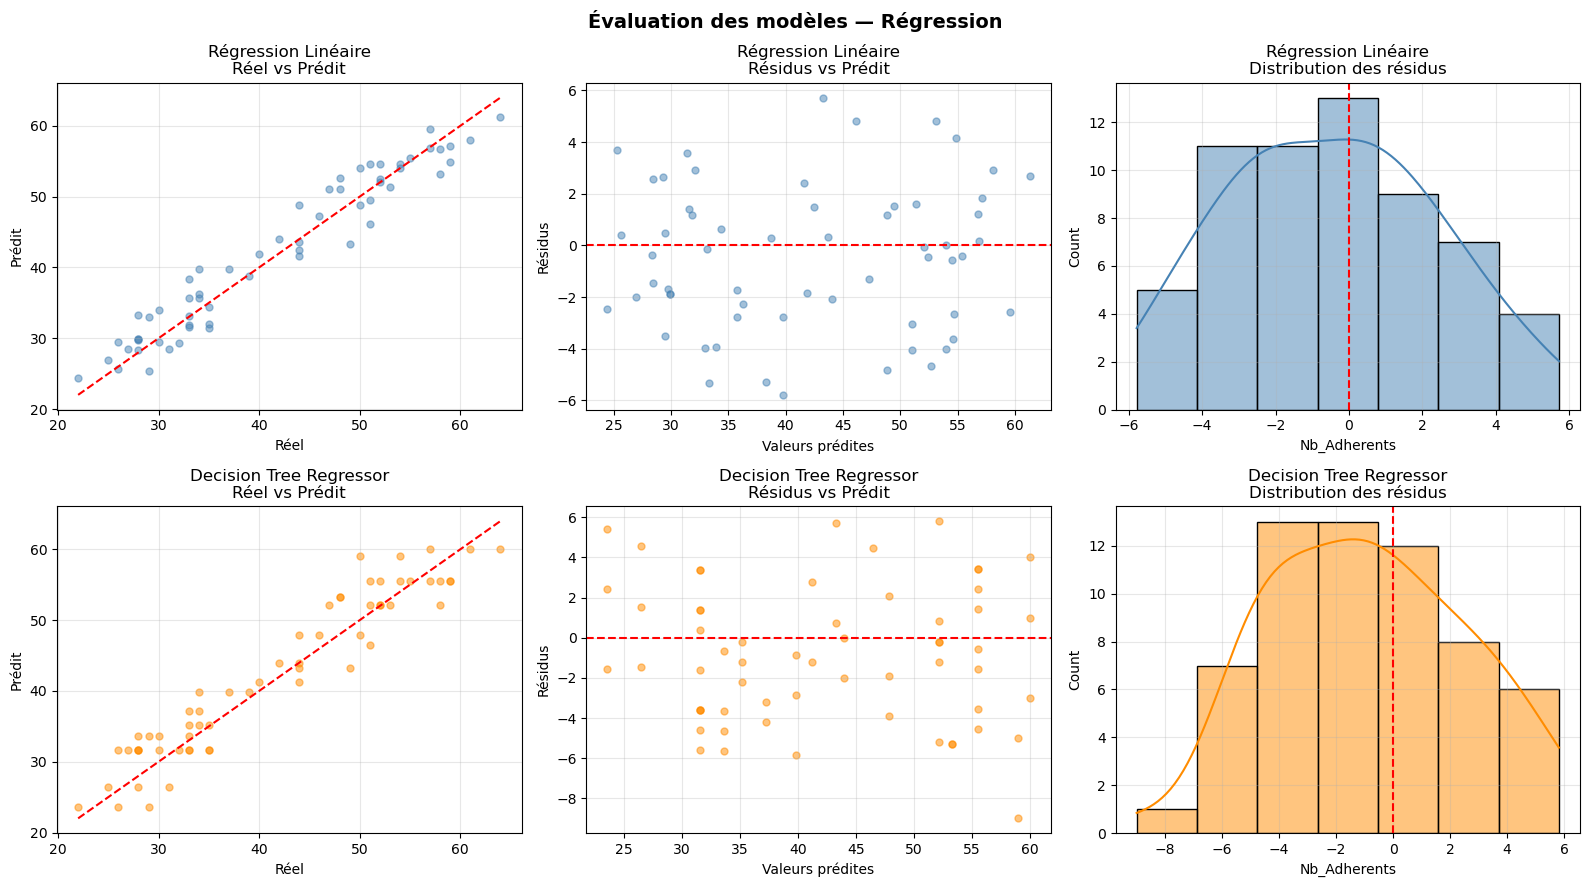

In [13]:
# ── Graphiques d'évaluation ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Évaluation des modèles — Régression", fontsize=14, fontweight='bold')

for i, (name, y_pred, color) in enumerate([
        ("Régression Linéaire",    y_pred_lr, "steelblue"),
        ("Decision Tree Regressor", y_pred_dt, "darkorange")]):
    row = i
    resid = y_test - y_pred

    # Réel vs Prédit
    axes[row,0].scatter(y_test, y_pred, alpha=0.5, color=color, s=25)
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    axes[row,0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
    axes[row,0].set_xlabel("Réel"); axes[row,0].set_ylabel("Prédit")
    axes[row,0].set_title(f"{name}\nRéel vs Prédit")
    axes[row,0].grid(alpha=0.3)

    # Résidus vs Prédit
    axes[row,1].scatter(y_pred, resid, alpha=0.5, color=color, s=25)
    axes[row,1].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[row,1].set_xlabel("Valeurs prédites"); axes[row,1].set_ylabel("Résidus")
    axes[row,1].set_title(f"{name}\nRésidus vs Prédit")
    axes[row,1].grid(alpha=0.3)

    # Distribution des résidus
    sns.histplot(resid, kde=True, ax=axes[row,2], color=color)
    axes[row,2].set_title(f"{name}\nDistribution des résidus")
    axes[row,2].axvline(0, color='red', linestyle='--')
    axes[row,2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# ── Vérification hypothèses (Shapiro-Wilk sur les résidus) ───
resid_lr = y_test - y_pred_lr
resid_dt = y_test - y_pred_dt

stat_lr, p_lr = stats.shapiro(resid_lr)
stat_dt, p_dt = stats.shapiro(resid_dt)

print("Test de Shapiro-Wilk — normalité des résidus :")
print(f"  Régression Linéaire     : stat={stat_lr:.4f}  p={p_lr:.4f} "
      f"→ {'✅ Normaux' if p_lr > 0.05 else '⚠️ Non normaux'}")
print(f"  Decision Tree Regressor : stat={stat_dt:.4f}  p={p_dt:.4f} "
      f"→ {'✅ Normaux' if p_dt > 0.05 else '⚠️ Non normaux'}")

Test de Shapiro-Wilk — normalité des résidus :
  Régression Linéaire     : stat=0.9819  p=0.5152 → ✅ Normaux
  Decision Tree Regressor : stat=0.9774  p=0.3280 → ✅ Normaux


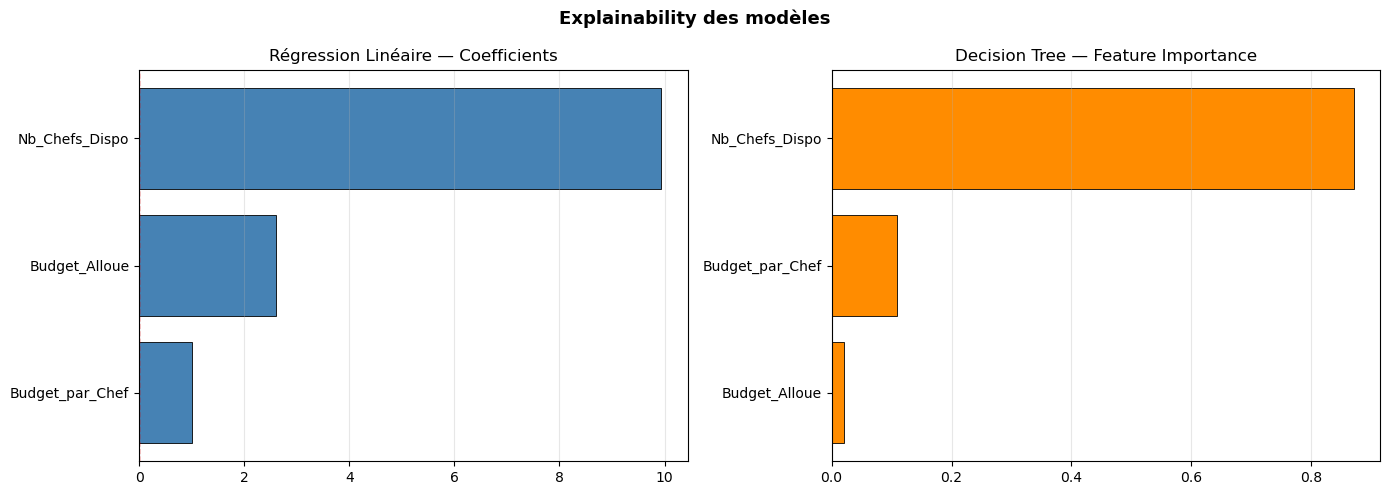


Intercept Régression Linéaire : 42.2147
Coefficients :
  Nb_Chefs_Dispo         : 9.9397
  Budget_par_Chef        : 0.9984
  Budget_Alloue          : 2.6080


In [15]:
# ── Feature importance & coefficients ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Explainability des modèles", fontsize=13, fontweight='bold')

# Coefficients Régression Linéaire
coef_df = pd.DataFrame({'Feature': selected, 'Coefficient': model_lr.coef_}
                       ).sort_values('Coefficient', key=abs, ascending=True)
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue', edgecolor='black', linewidth=0.6)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title("Régression Linéaire — Coefficients")
axes[0].grid(axis='x', alpha=0.3)

# Feature importance Decision Tree
fi_df = pd.DataFrame({'Feature': selected,
                      'Importance': best_dt.feature_importances_}
                     ).sort_values('Importance', ascending=True)
axes[1].barh(fi_df['Feature'], fi_df['Importance'], color='darkorange', edgecolor='black', linewidth=0.6)
axes[1].set_title("Decision Tree — Feature Importance")
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nIntercept Régression Linéaire : {model_lr.intercept_:.4f}")
print("Coefficients :")
for f, c in zip(selected, model_lr.coef_):
    print(f"  {f:<22} : {c:.4f}")

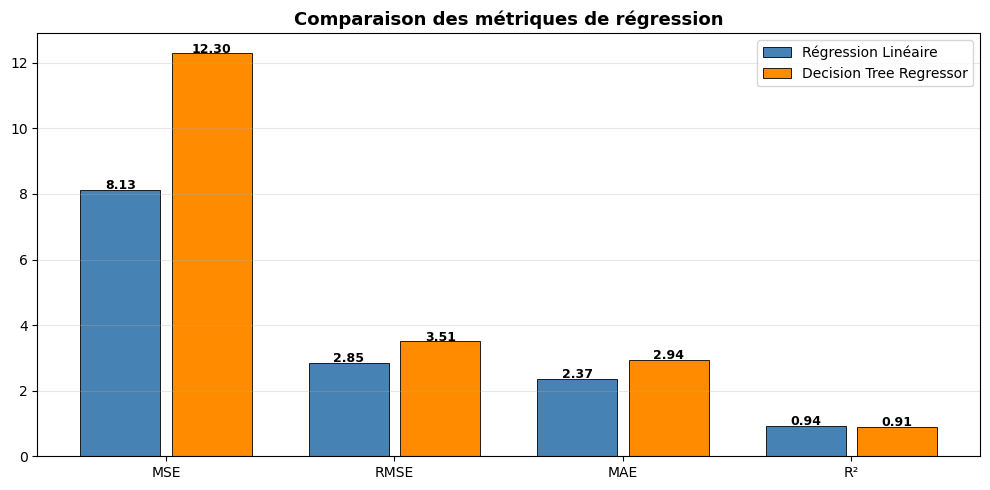

In [16]:
# ── Comparaison métriques (barres) ────────────────────────────
metrics_names = ['MSE', 'RMSE', 'MAE', 'R²']
vals_lr = [m_lr[m] for m in metrics_names]
vals_dt = [m_dt[m] for m in metrics_names]

x = np.arange(len(metrics_names))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - 0.2, vals_lr, 0.35, label='Régression Linéaire',   color='steelblue',  edgecolor='black', linewidth=0.6)
bars2 = ax.bar(x + 0.2, vals_dt, 0.35, label='Decision Tree Regressor', color='darkorange', edgecolor='black', linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_title("Comparaison des métriques de régression", fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Tuning & Validation

Validation croisée K-Fold (k=5) appliquée sur les deux modèles pour estimer la performance généralisable.

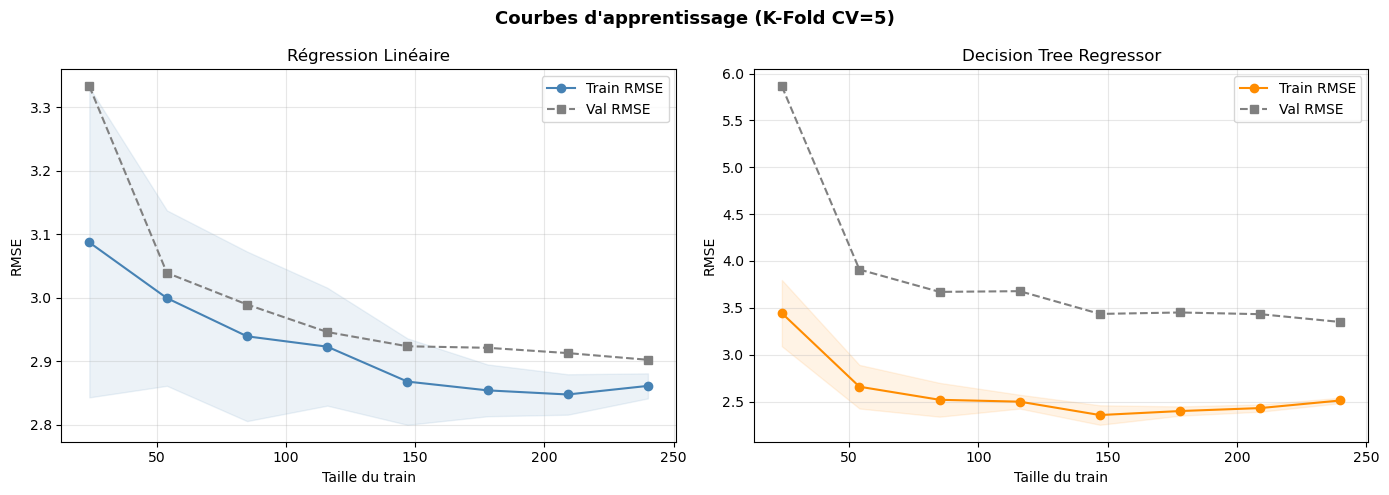

In [17]:
# ── Courbe d'apprentissage ────────────────────────────────────
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Courbes d'apprentissage (K-Fold CV=5)", fontsize=13, fontweight='bold')

for ax, (name, model, color) in zip(axes, [
        ("Régression Linéaire",    model_lr, "steelblue"),
        ("Decision Tree Regressor", best_dt,  "darkorange")]):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=kf, scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)
    train_rmse = -train_scores.mean(axis=1)
    val_rmse   = -val_scores.mean(axis=1)
    ax.plot(train_sizes, train_rmse, 'o-', color=color, label='Train RMSE')
    ax.plot(train_sizes, val_rmse,   's--', color='gray', label='Val RMSE')
    ax.fill_between(train_sizes,
                    -train_scores.mean(1) - train_scores.std(1),
                    -train_scores.mean(1) + train_scores.std(1), alpha=0.1, color=color)
    ax.set_title(name); ax.set_xlabel("Taille du train"); ax.set_ylabel("RMSE")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Exemple d'Application — Prédiction

In [18]:
import joblib

# Exemple de prédiction sur un nouveau scout
new_data_raw = pd.DataFrame({
    'Saison_Debut':   [2026],
    'Nb_Chefs_Dispo': [4],
    'Budget_Alloue':  [1800.0],
    'Unite_enc':      [le.transform(['Scouts'])[0]],
    'Budget_par_Chef':[1800.0 / 4],
    'Saison_Recente': [1]
})
# Appliquer le scaler sur les bonnes colonnes
new_scaled = new_data_raw.copy()
new_scaled[features_to_scale] = scaler.transform(new_data_raw[features_to_scale])
new_scaled['Budget_par_Chef'] = (new_data_raw['Budget_par_Chef']
                                  - df['Budget_Alloue'].mean()/df['Nb_Chefs_Dispo'].mean()) / 50
new_input = new_scaled[selected]
print(f"Prédiction Nb Adhérents ({best_name}) : {best_model.predict(new_input)[0]:.0f}")

Prédiction Nb Adhérents (Régression Linéaire) : 50


In [19]:
# ── Sauvegarde du modèle ─────────────────────────────────────
joblib.dump(best_model, 'prediction_adherents_model.pkl')
joblib.dump(le,         'prediction_adherents_encoder.pkl')
joblib.dump(scaler,     'prediction_adherents_scaler.pkl')
print("✅ Modèle sauvegardé → prediction_adherents_model.pkl")

✅ Modèle sauvegardé → prediction_adherents_model.pkl


## Conclusion

Les deux modèles (Régression Linéaire et Decision Tree Regressor) ont été entraînés, validés par **K-Fold cross-validation (k=5)** et évalués sur les métriques **MSE, RMSE, MAE, R²**.  
Le meilleur modèle est sélectionné automatiquement et exporté avec son pipeline de preprocessing.

**Points clés :**
- La Régression Linéaire est interprétable via ses coefficients.
- Le Decision Tree capture les non-linéarités et fournit une importance des features.
- Les résidus ont été analysés visuellement et via le test de Shapiro-Wilk.